<a href="https://colab.research.google.com/github/azrasm/waste-classification/blob/main/Evaluacija_finalnog_modela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projekat (LV8) - **Evaluacija i vizualizacija**
*model treniran sa *class_weights*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/POOS projekat/resnet50_waste_classifier_best.keras"
)

#Učitavanje svih test batchova
test_dir = "/content/drive/MyDrive/POOS projekat/PROCESSED_DATASET/TEST"
X_all, y_all = [], []

for fname in os.listdir(test_dir):
    if fname.endswith(".npz"):
        batch = np.load(os.path.join(test_dir, fname))
        X_all.append(batch['X'])
        y_all.append(batch['y'])

#Spajanje svih batchova u jedan dataset
X_full = np.concatenate(X_all, axis=0)
y_full = np.concatenate(y_all, axis=0)

print("Ukupno testnih slika:", X_full.shape[0])

Ukupno testnih slika: 2513


Učitan model i svi .npz fajlovi iz TEST foldera. Na kraju imamo X_full (sve slike) i y_full (sve labele).

In [ ]:
#PREDIKCIJA
#Model vraća vjerovatnoće
y_probs = model.predict(X_full)

#Pretvaranje vjerovatnoće u binarne klase (0 = organic, 1 = recyclable)
y_pred = (y_probs > 0.5).astype(int).flatten()

79/79 ━━━━━━━━━━━━━━━━━━━━ 552s 7s/step


Pošto je izlaz modela sigmoid, vrijednosti su između 0 i 1. Prag 0.5 dijeli klase:

≤ 0.5 → organic (0)

0.5 → recyclable (1)

In [ ]:
#METRIKE PERFORMANSI
accuracy  = accuracy_score(y_full, y_pred)
precision = precision_score(y_full, y_pred)
recall    = recall_score(y_full, y_pred)
f1        = f1_score(y_full, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_full, y_pred, target_names=["Organic", "Recyclable"]))

Accuracy : 0.7911
Precision: 0.7346
Recall   : 0.8264
F1-score : 0.7778
              precision    recall  f1-score   support

     Organic       0.85      0.76      0.80      1401
  Recyclable       0.73      0.83      0.78      1112

    accuracy                           0.79      2513
   macro avg       0.79      0.79      0.79      2513
weighted avg       0.80      0.79      0.79      2513



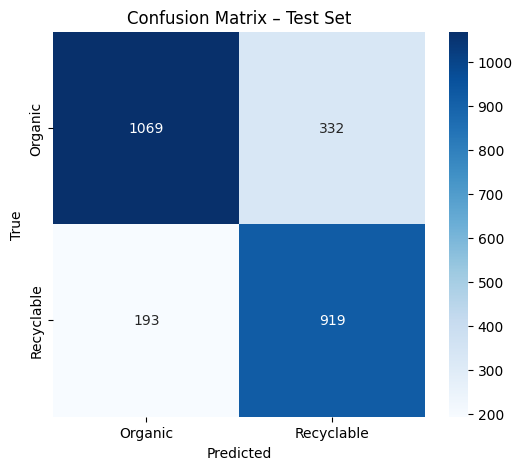

In [ ]:
#CONFUSION MATRIX
cm = confusion_matrix(y_full, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Organic","Recyclable"],
            yticklabels=["Organic","Recyclable"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Test Set")
plt.show()

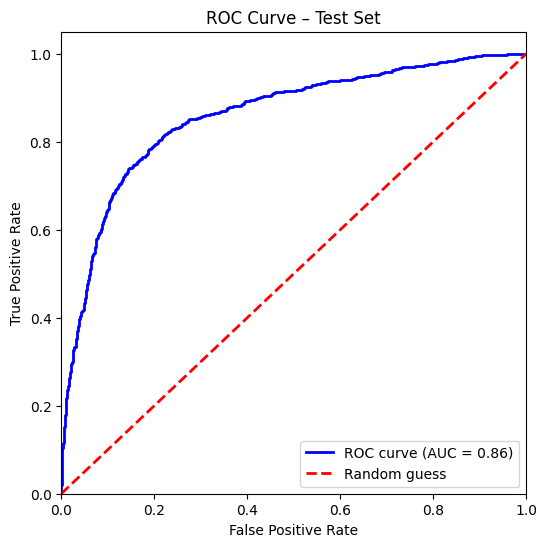

In [ ]:
#ROC kriva
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_full, y_probs)  # y_probs = vjerovatnoće iz modela
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Test Set')
plt.legend(loc="lower right")
plt.show()

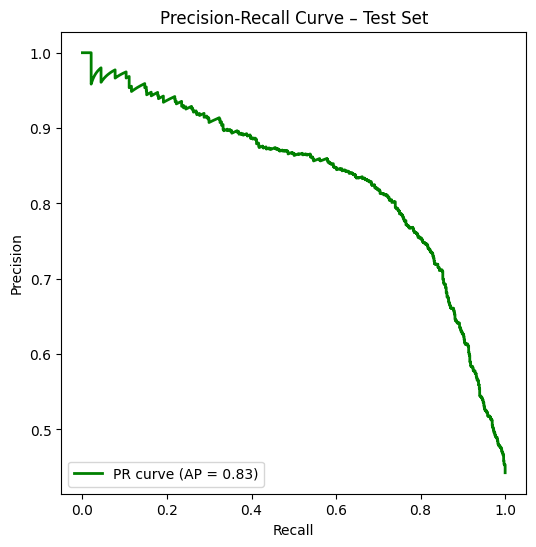

In [ ]:
#PRECISION-RECALL kriva
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_full, y_probs)
avg_precision = average_precision_score(y_full, y_probs)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – Test Set')
plt.legend(loc="lower left")
plt.show()

**Vizualizacija predikcija**

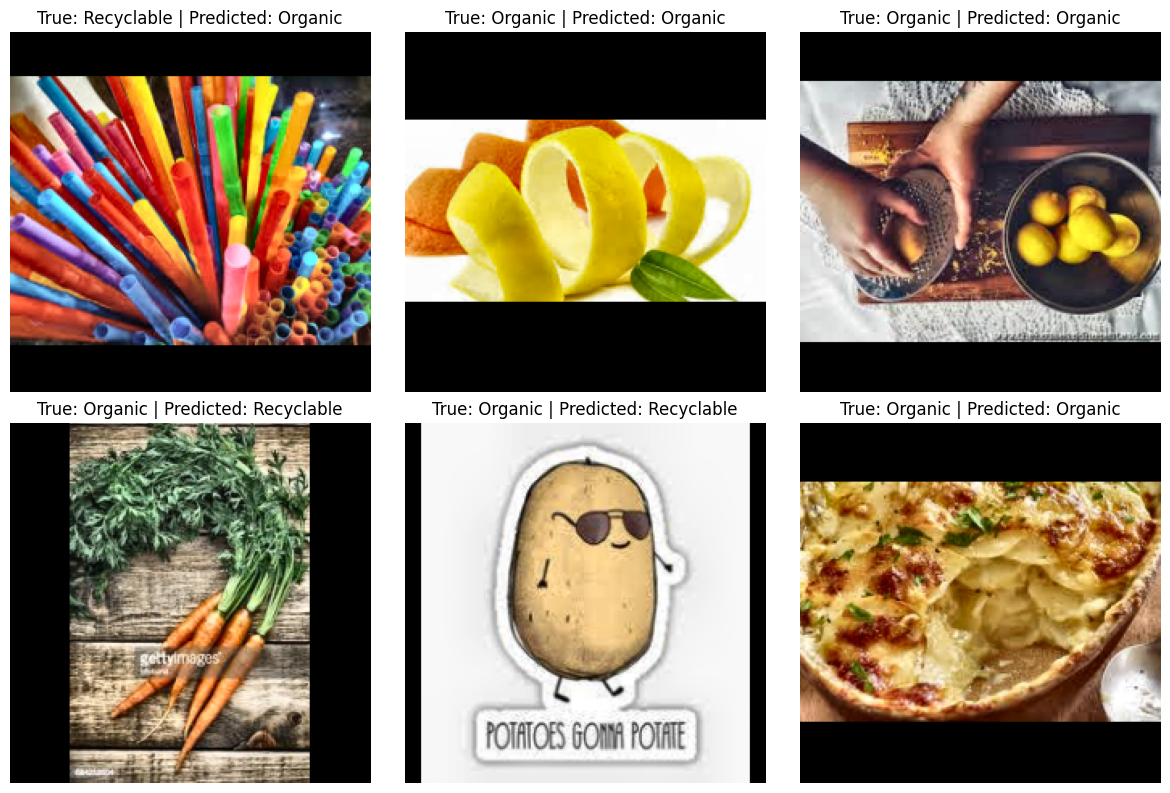

In [ ]:
import random

indices = random.sample(range(len(X_full)), 6)

plt.figure(figsize=(12,8))
for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_full[idx])
    pred = 'Recyclable' if y_pred[idx] == 1 else 'Organic'
    true = 'Recyclable' if y_full[idx] == 1 else 'Organic'
    plt.title(f"True: {true} | Predicted: {pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Nasumično se biraju slike iz testnog skupa i prikazuje predikcija i stvarna klasa. To daje intuitivnu sliku gdje model radi dobro, a gdje griješi.